In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile
import shutil
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/DERİNMODEL")

RAW_DATA_DIR = PROJECT_DIR / "01_veri_seti" / "ham_veri"
PROCESSED_DATA_DIR = PROJECT_DIR / "01_veri_seti" / "islenmis_veri"
MANIFEST_DIR = PROJECT_DIR / "01_veri_seti" / "veri_manifestleri"

NOTEBOOK_DIR = PROJECT_DIR / "02_notebooklar"

OUTPUT_DIR = PROJECT_DIR / "03_ciktilar"
GRAPH_DIR = OUTPUT_DIR / "grafikler"
TABLE_DIR = OUTPUT_DIR / "tablolar"
SAMPLE_DIR = OUTPUT_DIR / "ornek_gorseller"
MODEL_SUMMARY_DIR = OUTPUT_DIR / "model_ozetleri"

MODEL_DIR = PROJECT_DIR / "04_modeller"

for path in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MANIFEST_DIR,
    NOTEBOOK_DIR,
    GRAPH_DIR,
    TABLE_DIR,
    SAMPLE_DIR,
    MODEL_SUMMARY_DIR,
    MODEL_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Proje klasörleri hazır.")
print(PROJECT_DIR)

Proje klasörleri hazır.
/content/drive/MyDrive/DERİNMODEL


In [3]:
zip_path = PROJECT_DIR / "archive (5).zip"

print("ZIP var mı?:", zip_path.exists())
print("ZIP yolu:", zip_path)

ZIP var mı?: True
ZIP yolu: /content/drive/MyDrive/DERİNMODEL/archive (5).zip


In [4]:
import zipfile
import os

extract_dir = RAW_DATA_DIR / "dagm_2007"

if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print("ZIP başarıyla çıkarıldı.")
else:
    print("Veri seti klasörü zaten var, tekrar çıkarılmadı.")

print("\nÇıkarılan ana klasör içeriği:")
for item in os.listdir(extract_dir):
    print("-", item)

ZIP başarıyla çıkarıldı.

Çıkarılan ana klasör içeriği:
- DAGM_KaggleUpload
- dagm_kaggleupload


In [5]:
from pathlib import Path
import os

extract_dir = RAW_DATA_DIR / "dagm_2007"

print("Ana çıkarma klasörü:", extract_dir)
print("İçerik:")

for item in sorted(extract_dir.iterdir()):
    if item.is_dir():
        print("\nKLASÖR:", item.name)
        sub_items = sorted([x.name for x in item.iterdir()])[:20]
        print("İlk içerikler:", sub_items)
        print("Toplam alt öğe:", len(list(item.iterdir())))
    else:
        print("DOSYA:", item.name)

Ana çıkarma klasörü: /content/drive/MyDrive/DERİNMODEL/01_veri_seti/ham_veri/dagm_2007
İçerik:

KLASÖR: DAGM_KaggleUpload
İlk içerikler: ['Class1', 'Class10', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6', 'Class7', 'Class8', 'Class9']
Toplam alt öğe: 10

KLASÖR: dagm_kaggleupload
İlk içerikler: ['DAGM_KaggleUpload']
Toplam alt öğe: 1


In [6]:
DATASET_ROOT = RAW_DATA_DIR / "dagm_2007" / "DAGM_KaggleUpload"

print("Kullanılacak veri seti kökü:")
print(DATASET_ROOT)
print("Var mı?:", DATASET_ROOT.exists())

class_folders = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])

print("\nBulunan class klasörleri:")
for class_path in class_folders:
    print("-", class_path.name)

Kullanılacak veri seti kökü:
/content/drive/MyDrive/DERİNMODEL/01_veri_seti/ham_veri/dagm_2007/DAGM_KaggleUpload
Var mı?: True

Bulunan class klasörleri:
- Class1
- Class10
- Class2
- Class3
- Class4
- Class5
- Class6
- Class7
- Class8
- Class9


In [7]:
import pandas as pd

dataset_structure_records = []

for class_path in class_folders:
    class_name = class_path.name

    for split_name in ["Train", "Test"]:
        split_path = class_path / split_name
        label_path = split_path / "Label"

        if split_path.exists():
            image_files = [
                f for f in split_path.iterdir()
                if f.is_file() and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]
            ]
        else:
            image_files = []

        if label_path.exists():
            label_files = [
                f for f in label_path.iterdir()
                if f.is_file() and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]
            ]
        else:
            label_files = []

        dataset_structure_records.append({
            "class": class_name,
            "split": split_name,
            "gorsel_sayisi": len(image_files),
            "label_klasoru_var_mi": label_path.exists(),
            "label_dosya_sayisi": len(label_files)
        })

dataset_structure_df = pd.DataFrame(dataset_structure_records)

structure_path = TABLE_DIR / "dagm_2007_klasor_yapisi.csv"
dataset_structure_df.to_csv(structure_path, index=False)

print("Klasör yapısı tablosu kaydedildi:")
print(structure_path)

dataset_structure_df

Klasör yapısı tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_klasor_yapisi.csv


,class,split,gorsel_sayisi,label_klasoru_var_mi,label_dosya_sayisi
0,Class1,Train,575,True,79
1,Class1,Test,575,True,71
2,Class10,Train,1150,True,150
3,Class10,Test,1150,True,150
4,Class2,Train,575,True,66
5,Class2,Test,575,True,84
6,Class3,Train,575,True,66
7,Class3,Test,575,True,84
8,Class4,Train,575,True,82
9,Class4,Test,575,True,68


In [8]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = RAW_DATA_DIR / "dagm_2007" / "DAGM_KaggleUpload"

manifest_records = []

for class_path in sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()]):
    class_name = class_path.name

    for split_name in ["Train", "Test"]:
        split_path = class_path / split_name
        label_path = split_path / "Label"

        image_files = sorted([
            f for f in split_path.iterdir()
            if f.is_file() and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]
        ])

        label_files = set()
        if label_path.exists():
            label_files = set([
                f.name for f in label_path.iterdir()
                if f.is_file() and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]
            ])

        for image_file in image_files:
            has_defect = image_file.name in label_files

            manifest_records.append({
                "class": class_name,
                "split": split_name,
                "dosya_adi": image_file.name,
                "image_path": str(image_file),
                "label_path": str(label_path / image_file.name) if has_defect else "",
                "hedef": 1 if has_defect else 0,
                "hedef_adi": "kusurlu" if has_defect else "kusursuz"
            })

manifest_df = pd.DataFrame(manifest_records)

manifest_path = TABLE_DIR / "dagm_2007_binary_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Manifest tablosu kaydedildi:")
print(manifest_path)

print("\nToplam kayıt:", len(manifest_df))
print("\nSplit dağılımı:")
print(manifest_df["split"].value_counts())

print("\nHedef dağılımı:")
print(manifest_df["hedef_adi"].value_counts())

print("\nSplit bazında hedef dağılımı:")
display(pd.crosstab(manifest_df["split"], manifest_df["hedef_adi"]))

manifest_df.head()

Manifest tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_binary_manifest.csv

Toplam kayıt: 16100

Split dağılımı:
split
Train    8050
Test     8050
Name: count, dtype: int64

Hedef dağılımı:
hedef_adi
kusursuz    16100
Name: count, dtype: int64

Split bazında hedef dağılımı:


hedef_adi,kusursuz
split,
Test,8050
Train,8050


,class,split,dosya_adi,image_path,label_path,hedef,hedef_adi
0,Class1,Train,0576.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,0,kusursuz
1,Class1,Train,0577.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,0,kusursuz
2,Class1,Train,0578.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,0,kusursuz
3,Class1,Train,0579.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,0,kusursuz
4,Class1,Train,0580.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,0,kusursuz


In [9]:
from pathlib import Path

DATASET_ROOT = RAW_DATA_DIR / "dagm_2007" / "DAGM_KaggleUpload"

for class_name in ["Class1", "Class2", "Class3", "Class4", "Class5", "Class6"]:
    for split_name in ["Train", "Test"]:
        label_dir = DATASET_ROOT / class_name / split_name / "Label"

        print("\n", class_name, split_name)
        print("Label klasörü var mı?:", label_dir.exists())

        if label_dir.exists():
            label_files = sorted([p.name for p in label_dir.iterdir() if p.is_file()])
            print("Label dosya sayısı:", len(label_files))
            print("İlk 10 label dosyası:", label_files[:10])


 Class1 Train
Label klasörü var mı?: True
Label dosya sayısı: 81
İlk 10 label dosyası: ['0595_label.PNG', '0616_label.PNG', '0626_label.PNG', '0634_label.PNG', '0635_label.PNG', '0646_label.PNG', '0658_label.PNG', '0663_label.PNG', '0664_label.PNG', '0672_label.PNG']

 Class1 Test
Label klasörü var mı?: True
Label dosya sayısı: 73
İlk 10 label dosyası: ['0002_label.PNG', '0010_label.PNG', '0021_label.PNG', '0027_label.PNG', '0032_label.PNG', '0035_label.PNG', '0041_label.PNG', '0043_label.PNG', '0048_label.PNG', '0060_label.PNG']

 Class2 Train
Label klasörü var mı?: True
Label dosya sayısı: 67
İlk 10 label dosyası: ['0576_label.PNG', '0578_label.PNG', '0579_label.PNG', '0580_label.PNG', '0588_label.PNG', '0596_label.PNG', '0620_label.PNG', '0624_label.PNG', '0632_label.PNG', '0635_label.PNG']

 Class2 Test
Label klasörü var mı?: True
Label dosya sayısı: 85
İlk 10 label dosyası: ['0003_label.PNG', '0007_label.PNG', '0009_label.PNG', '0013_label.PNG', '0014_label.PNG', '0017_label.PNG'

In [10]:
from pathlib import Path
import pandas as pd
import os

DATASET_ROOT = RAW_DATA_DIR / "dagm_2007" / "DAGM_KaggleUpload"

SELECTED_CLASSES = ["Class1", "Class2", "Class3", "Class4", "Class5", "Class6"]

manifest_records = []

for class_name in SELECTED_CLASSES:
    for split_name in ["Train", "Test"]:
        image_dir = DATASET_ROOT / class_name / split_name
        label_dir = image_dir / "Label"

        image_files = sorted([
            p for p in image_dir.iterdir()
            if p.is_file() and p.suffix.lower() in [".png", ".jpg", ".jpeg"]
        ])

        label_names = set()
        if label_dir.exists():
            label_names = set([p.name for p in label_dir.iterdir() if p.is_file()])

        for image_path in image_files:
            image_stem = image_path.stem
            expected_label_name = f"{image_stem}_label.PNG"

            has_label = expected_label_name in label_names

            manifest_records.append({
                "class": class_name,
                "split": split_name,
                "dosya_adi": image_path.name,
                "image_path": str(image_path),
                "label_dosyasi": expected_label_name if has_label else "",
                "label_path": str(label_dir / expected_label_name) if has_label else "",
                "hedef": 1 if has_label else 0,
                "hedef_adi": "kusurlu" if has_label else "kusursuz"
            })

manifest_df = pd.DataFrame(manifest_records)

manifest_path = TABLE_DIR / "dagm_2007_binary_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Manifest tablosu kaydedildi:")
print(manifest_path)

print("\nToplam kayıt:", len(manifest_df))

print("\nGenel hedef dağılımı:")
print(manifest_df["hedef_adi"].value_counts())

print("\nSplit dağılımı:")
print(manifest_df["split"].value_counts())

print("\nSplit bazında hedef dağılımı:")
print(pd.crosstab(manifest_df["split"], manifest_df["hedef_adi"]))

print("\nClass bazında hedef dağılımı:")
print(pd.crosstab(manifest_df["class"], manifest_df["hedef_adi"]))

manifest_df.head()

Manifest tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_binary_manifest.csv

Toplam kayıt: 6900

Genel hedef dağılımı:
hedef_adi
kusursuz    6000
kusurlu      900
Name: count, dtype: int64

Split dağılımı:
split
Train    3450
Test     3450
Name: count, dtype: int64

Split bazında hedef dağılımı:
hedef_adi  kusurlu  kusursuz
split                       
Test           454      2996
Train          446      3004

Class bazında hedef dağılımı:
hedef_adi  kusurlu  kusursuz
class                       
Class1         150      1000
Class2         150      1000
Class3         150      1000
Class4         150      1000
Class5         150      1000
Class6         150      1000


,class,split,dosya_adi,image_path,label_dosyasi,label_path,hedef,hedef_adi
0,Class1,Train,0576.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
1,Class1,Train,0577.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
2,Class1,Train,0578.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
3,Class1,Train,0579.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
4,Class1,Train,0580.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Kayıt klasörleri
GRAPH_ANALYSIS_DIR = GRAPH_DIR / "1_veri_seti_analizi"
GRAPH_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

TABLE_ANALYSIS_DIR = TABLE_DIR
TABLE_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# 1) Genel hedef dağılımı tablosu
target_counts = manifest_df["hedef_adi"].value_counts().reset_index()
target_counts.columns = ["hedef_adi", "gorsel_sayisi"]
target_counts["oran"] = (target_counts["gorsel_sayisi"] / target_counts["gorsel_sayisi"].sum() * 100).round(2)

target_counts_path = TABLE_ANALYSIS_DIR / "dagm_2007_genel_hedef_dagilimi.csv"
target_counts.to_csv(target_counts_path, index=False)

print("Genel hedef dağılımı tablosu kaydedildi:")
print(target_counts_path)

target_counts

Genel hedef dağılımı tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_genel_hedef_dagilimi.csv


,hedef_adi,gorsel_sayisi,oran
0,kusursuz,6000,86.96
1,kusurlu,900,13.04


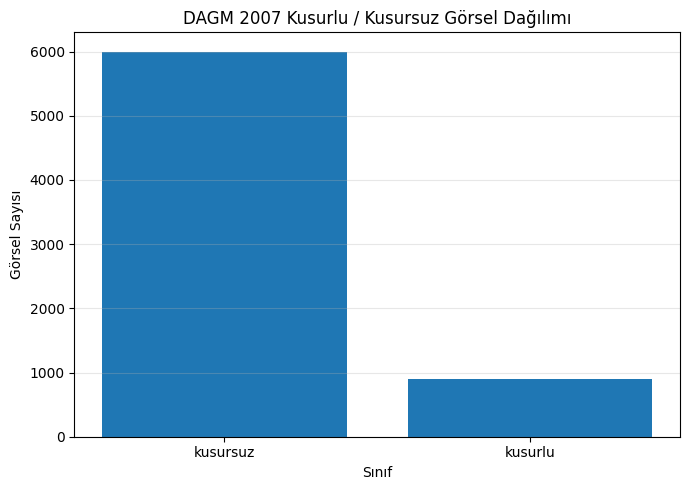

Genel hedef dağılımı grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/1_veri_seti_analizi/dagm_2007_kusurlu_kusursuz_dagilimi.png


In [12]:
plt.figure(figsize=(7, 5))
plt.bar(target_counts["hedef_adi"], target_counts["gorsel_sayisi"])
plt.title("DAGM 2007 Kusurlu / Kusursuz Görsel Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Görsel Sayısı")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

target_graph_path = GRAPH_ANALYSIS_DIR / "dagm_2007_kusurlu_kusursuz_dagilimi.png"
plt.savefig(target_graph_path, dpi=300)
plt.show()

print("Genel hedef dağılımı grafiği kaydedildi:")
print(target_graph_path)

In [13]:
# Class bazında kusurlu / kusursuz dağılım tablosu

class_target_counts = manifest_df.groupby(["class", "hedef_adi"]).size().reset_index(name="gorsel_sayisi")

class_target_pivot = class_target_counts.pivot(
    index="class",
    columns="hedef_adi",
    values="gorsel_sayisi"
).fillna(0).reset_index()

class_target_pivot["toplam"] = class_target_pivot["kusurlu"] + class_target_pivot["kusursuz"]
class_target_pivot["kusurlu_oran"] = (class_target_pivot["kusurlu"] / class_target_pivot["toplam"] * 100).round(2)
class_target_pivot["kusursuz_oran"] = (class_target_pivot["kusursuz"] / class_target_pivot["toplam"] * 100).round(2)

class_target_path = TABLE_ANALYSIS_DIR / "dagm_2007_class_bazli_hedef_dagilimi.csv"
class_target_pivot.to_csv(class_target_path, index=False)

print("Class bazlı hedef dağılımı tablosu kaydedildi:")
print(class_target_path)

class_target_pivot

Class bazlı hedef dağılımı tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_class_bazli_hedef_dagilimi.csv


hedef_adi,class,kusurlu,kusursuz,toplam,kusurlu_oran,kusursuz_oran
0,Class1,150,1000,1150,13.04,86.96
1,Class2,150,1000,1150,13.04,86.96
2,Class3,150,1000,1150,13.04,86.96
3,Class4,150,1000,1150,13.04,86.96
4,Class5,150,1000,1150,13.04,86.96
5,Class6,150,1000,1150,13.04,86.96


<Figure size 1000x600 with 0 Axes>

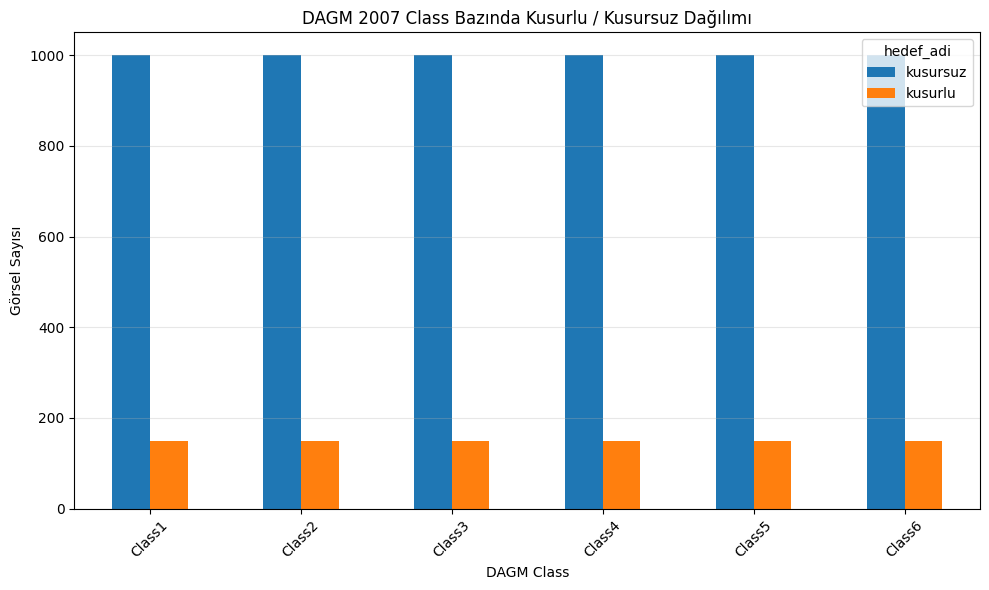

Class bazlı hedef dağılımı grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/1_veri_seti_analizi/dagm_2007_class_bazli_kusurlu_kusursuz_dagilimi.png


In [14]:
# Class bazında kusurlu / kusursuz dağılım grafiği

class_target_pivot_plot = class_target_pivot.set_index("class")[["kusursuz", "kusurlu"]]

plt.figure(figsize=(10, 6))
class_target_pivot_plot.plot(kind="bar", figsize=(10, 6))

plt.title("DAGM 2007 Class Bazında Kusurlu / Kusursuz Dağılımı")
plt.xlabel("DAGM Class")
plt.ylabel("Görsel Sayısı")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

class_target_graph_path = GRAPH_ANALYSIS_DIR / "dagm_2007_class_bazli_kusurlu_kusursuz_dagilimi.png"
plt.savefig(class_target_graph_path, dpi=300)
plt.show()

print("Class bazlı hedef dağılımı grafiği kaydedildi:")
print(class_target_graph_path)

In [15]:
# Train/Test bazında kusurlu - kusursuz dağılım tablosu

split_target_counts = manifest_df.groupby(["split", "hedef_adi"]).size().reset_index(name="gorsel_sayisi")

split_target_pivot = split_target_counts.pivot(
    index="split",
    columns="hedef_adi",
    values="gorsel_sayisi"
).fillna(0).reset_index()

split_target_pivot["toplam"] = split_target_pivot["kusurlu"] + split_target_pivot["kusursuz"]
split_target_pivot["kusurlu_oran"] = (split_target_pivot["kusurlu"] / split_target_pivot["toplam"] * 100).round(2)
split_target_pivot["kusursuz_oran"] = (split_target_pivot["kusursuz"] / split_target_pivot["toplam"] * 100).round(2)

split_target_path = TABLE_ANALYSIS_DIR / "dagm_2007_train_test_hedef_dagilimi.csv"
split_target_pivot.to_csv(split_target_path, index=False)

print("Train/Test hedef dağılımı tablosu kaydedildi:")
print(split_target_path)

split_target_pivot

Train/Test hedef dağılımı tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_train_test_hedef_dagilimi.csv


hedef_adi,split,kusurlu,kusursuz,toplam,kusurlu_oran,kusursuz_oran
0,Test,454,2996,3450,13.16,86.84
1,Train,446,3004,3450,12.93,87.07


<Figure size 800x500 with 0 Axes>

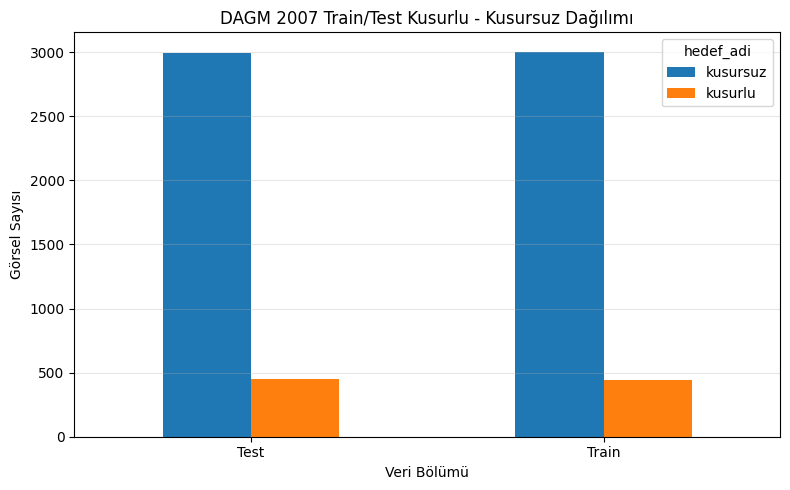

Train/Test hedef dağılımı grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/1_veri_seti_analizi/dagm_2007_train_test_kusurlu_kusursuz_dagilimi.png


In [16]:
# Train/Test bazında kusurlu - kusursuz dağılım grafiği

split_target_pivot_plot = split_target_pivot.set_index("split")[["kusursuz", "kusurlu"]]

plt.figure(figsize=(8, 5))
split_target_pivot_plot.plot(kind="bar", figsize=(8, 5))

plt.title("DAGM 2007 Train/Test Kusurlu - Kusursuz Dağılımı")
plt.xlabel("Veri Bölümü")
plt.ylabel("Görsel Sayısı")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

split_target_graph_path = GRAPH_ANALYSIS_DIR / "dagm_2007_train_test_kusurlu_kusursuz_dagilimi.png"
plt.savefig(split_target_graph_path, dpi=300)
plt.show()

print("Train/Test hedef dağılımı grafiği kaydedildi:")
print(split_target_graph_path)

In [17]:
import hashlib
import pandas as pd
from pathlib import Path

def file_md5(path):
    hash_md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

hash_records = []

for idx, row in manifest_df.iterrows():
    image_path = Path(row["image_path"])

    if image_path.exists():
        hash_records.append({
            "class": row["class"],
            "split": row["split"],
            "dosya_adi": row["dosya_adi"],
            "hedef_adi": row["hedef_adi"],
            "image_path": str(image_path),
            "md5_hash": file_md5(image_path)
        })

hash_df = pd.DataFrame(hash_records)

hash_path = TABLE_ANALYSIS_DIR / "dagm_2007_gorsel_hash_listesi.csv"
hash_df.to_csv(hash_path, index=False)

print("Hash tablosu kaydedildi:")
print(hash_path)

print("Toplam hash kaydı:", len(hash_df))
hash_df.head()

Hash tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_gorsel_hash_listesi.csv
Toplam hash kaydı: 6900


,class,split,dosya_adi,hedef_adi,image_path,md5_hash
0,Class1,Train,0576.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,b8fdf55b9bc6c179ab8897075367a45c
1,Class1,Train,0577.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,78aa0438ee63465fc5e65ffed3c3a0e9
2,Class1,Train,0578.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,22843dfdc8b9517d382720e4efca456b
3,Class1,Train,0579.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,8e4ad2d058626e96bf83670df20bad83
4,Class1,Train,0580.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,631b2acd454eec34630f215e9eb4a9ad


In [18]:
# Train/Test arasında birebir aynı görsel var mı?

train_hashes = set(hash_df[hash_df["split"] == "Train"]["md5_hash"])
test_hashes = set(hash_df[hash_df["split"] == "Test"]["md5_hash"])

common_hashes = train_hashes.intersection(test_hashes)

leakage_df = hash_df[hash_df["md5_hash"].isin(common_hashes)].sort_values("md5_hash")

leakage_path = TABLE_ANALYSIS_DIR / "dagm_2007_train_test_hash_sizintisi.csv"
leakage_df.to_csv(leakage_path, index=False)

print("Train benzersiz hash:", len(train_hashes))
print("Test benzersiz hash:", len(test_hashes))
print("Train-Test ortak hash sayısı:", len(common_hashes))
print("Ortak hash'e sahip toplam kayıt:", len(leakage_df))
print("Leakage tablosu kaydedildi:")
print(leakage_path)

leakage_df.head(20)

Train benzersiz hash: 3450
Test benzersiz hash: 3450
Train-Test ortak hash sayısı: 0
Ortak hash'e sahip toplam kayıt: 0
Leakage tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_train_test_hash_sizintisi.csv


,class,split,dosya_adi,hedef_adi,image_path,md5_hash


In [19]:
!pip install imagehash -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.6 MB/s eta 0:00:00


In [20]:
from PIL import Image
import imagehash
import pandas as pd
from pathlib import Path

phash_records = []

for idx, row in manifest_df.iterrows():
    image_path = Path(row["image_path"])

    if image_path.exists():
        try:
            img = Image.open(image_path).convert("L")
            avg_hash = imagehash.average_hash(img)
            phash = imagehash.phash(img)

            phash_records.append({
                "class": row["class"],
                "split": row["split"],
                "dosya_adi": row["dosya_adi"],
                "hedef_adi": row["hedef_adi"],
                "image_path": str(image_path),
                "avg_hash": str(avg_hash),
                "phash": str(phash)
            })
        except Exception as e:
            print("Hata:", image_path, e)

phash_df = pd.DataFrame(phash_records)

phash_path = TABLE_ANALYSIS_DIR / "dagm_2007_perceptual_hash_listesi.csv"
phash_df.to_csv(phash_path, index=False)

print("Perceptual hash tablosu kaydedildi:")
print(phash_path)
print("Toplam kayıt:", len(phash_df))

phash_df.head()

Perceptual hash tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_perceptual_hash_listesi.csv
Toplam kayıt: 6900


,class,split,dosya_adi,hedef_adi,image_path,avg_hash,phash
0,Class1,Train,0576.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,01078f07018b5757,aa57802b47a8bb5b
1,Class1,Train,0577.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,00000005070f0f0f,aa55ab55aa46abc1
2,Class1,Train,0578.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,e7c381000080c3c3,ffa6e10604de17a8
3,Class1,Train,0579.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,1303cfcf031333b7,ae51ae05bad58669
4,Class1,Train,0580.PNG,kusursuz,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,ce83030103c6ed7b,bb36c2d6a950b58a


In [21]:
import imagehash

train_phash_df = phash_df[phash_df["split"] == "Train"].reset_index(drop=True)
test_phash_df = phash_df[phash_df["split"] == "Test"].reset_index(drop=True)

train_hash_objects = [
    imagehash.hex_to_hash(h) for h in train_phash_df["phash"]
]

similar_records = []

for test_idx, test_row in test_phash_df.iterrows():
    test_hash = imagehash.hex_to_hash(test_row["phash"])

    min_distance = 999
    nearest_train_idx = None

    for train_idx, train_hash in enumerate(train_hash_objects):
        distance = test_hash - train_hash

        if distance < min_distance:
            min_distance = distance
            nearest_train_idx = train_idx

    nearest_train = train_phash_df.iloc[nearest_train_idx]

    similar_records.append({
        "test_class": test_row["class"],
        "test_dosya": test_row["dosya_adi"],
        "test_hedef": test_row["hedef_adi"],
        "train_class": nearest_train["class"],
        "en_benzer_train_dosya": nearest_train["dosya_adi"],
        "train_hedef": nearest_train["hedef_adi"],
        "hamming_mesafesi": min_distance
    })

similar_df = pd.DataFrame(similar_records)

similar_path = TABLE_ANALYSIS_DIR / "dagm_2007_train_test_yakin_benzerlik_kontrolu.csv"
similar_df.to_csv(similar_path, index=False)

print("Yakın benzerlik kontrol tablosu kaydedildi:")
print(similar_path)

print("\nHamming mesafesi özeti:")
print(similar_df["hamming_mesafesi"].describe())

similar_df.sort_values("hamming_mesafesi").head(30)

Yakın benzerlik kontrol tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_train_test_yakin_benzerlik_kontrolu.csv

Hamming mesafesi özeti:
count    3450.000000
mean        8.691594
std         7.508724
min         0.000000
25%         0.000000
50%         8.000000
75%        16.000000
max        22.000000
Name: hamming_mesafesi, dtype: float64


,test_class,test_dosya,test_hedef,train_class,en_benzer_train_dosya,train_hedef,hamming_mesafesi
2503,Class5,0204.PNG,kusursuz,Class5,0576.PNG,kusursuz,0
2502,Class5,0203.PNG,kusurlu,Class5,0581.PNG,kusursuz,0
2501,Class5,0202.PNG,kusursuz,Class5,0630.PNG,kusursuz,0
2532,Class5,0233.PNG,kusursuz,Class5,0718.PNG,kusursuz,0
2531,Class5,0232.PNG,kusursuz,Class5,0825.PNG,kusursuz,0
2529,Class5,0230.PNG,kusursuz,Class5,0630.PNG,kusursuz,0
2528,Class5,0229.PNG,kusursuz,Class5,0815.PNG,kusursuz,0
2527,Class5,0228.PNG,kusursuz,Class5,0578.PNG,kusursuz,0
2526,Class5,0227.PNG,kusursuz,Class5,0815.PNG,kusursuz,0
2525,Class5,0226.PNG,kusursuz,Class5,0683.PNG,kusursuz,0


In [22]:
# Hamming mesafesi özet tablosu

hamming_summary = similar_df["hamming_mesafesi"].describe().reset_index()
hamming_summary.columns = ["istatistik", "deger"]

hamming_summary_path = TABLE_ANALYSIS_DIR / "dagm_2007_yakin_benzerlik_ozeti.csv"
hamming_summary.to_csv(hamming_summary_path, index=False)

print("Yakın benzerlik özeti kaydedildi:")
print(hamming_summary_path)

hamming_summary

Yakın benzerlik özeti kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_yakin_benzerlik_ozeti.csv


,istatistik,deger
0,count,3450.000000
1,mean,8.691594
2,std,7.508724
3,min,0.000000
4,25%,0.000000
5,50%,8.000000
6,75%,16.000000
7,max,22.000000


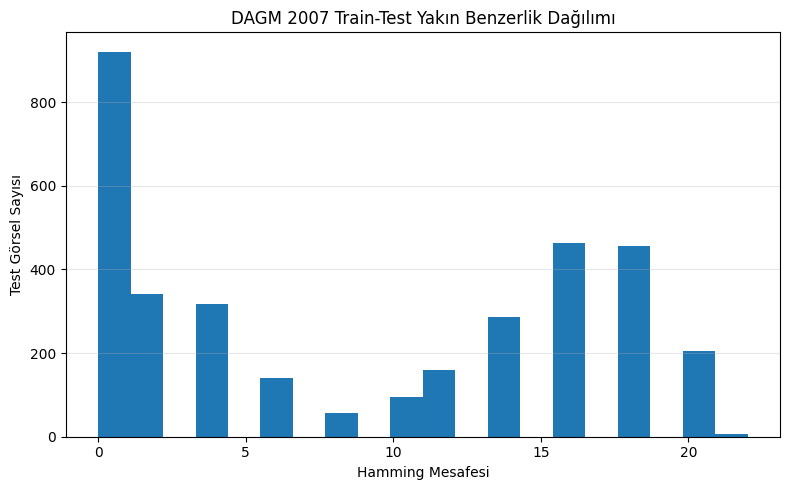

Yakın benzerlik grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/1_veri_seti_analizi/dagm_2007_train_test_yakin_benzerlik_dagilimi.png


In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(similar_df["hamming_mesafesi"], bins=20)
plt.title("DAGM 2007 Train-Test Yakın Benzerlik Dağılımı")
plt.xlabel("Hamming Mesafesi")
plt.ylabel("Test Görsel Sayısı")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

hamming_graph_path = GRAPH_ANALYSIS_DIR / "dagm_2007_train_test_yakin_benzerlik_dagilimi.png"
plt.savefig(hamming_graph_path, dpi=300)
plt.show()

print("Yakın benzerlik grafiği kaydedildi:")
print(hamming_graph_path)

In [24]:
# Hamming mesafesi 0 olan en yakın benzer örnekler

zero_similarity_df = similar_df[similar_df["hamming_mesafesi"] == 0].copy()

zero_similarity_path = TABLE_ANALYSIS_DIR / "dagm_2007_hamming_0_benzer_ornekler.csv"
zero_similarity_df.to_csv(zero_similarity_path, index=False)

print("Hamming 0 benzer örnekler kaydedildi:")
print(zero_similarity_path)

print("Hamming mesafesi 0 olan test örneği sayısı:", len(zero_similarity_df))

zero_similarity_df.head(30)

Hamming 0 benzer örnekler kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_hamming_0_benzer_ornekler.csv
Hamming mesafesi 0 olan test örneği sayısı: 921


,test_class,test_dosya,test_hedef,train_class,en_benzer_train_dosya,train_hedef,hamming_mesafesi
1150,Class3,0001.PNG,kusursuz,Class3,0810.PNG,kusursuz,0
1151,Class3,0002.PNG,kusursuz,Class3,0594.PNG,kusursuz,0
1152,Class3,0003.PNG,kusursuz,Class3,0720.PNG,kusurlu,0
1153,Class3,0004.PNG,kusursuz,Class3,1017.PNG,kusursuz,0
1154,Class3,0005.PNG,kusursuz,Class3,0588.PNG,kusursuz,0
1155,Class3,0006.PNG,kusursuz,Class3,0595.PNG,kusursuz,0
1157,Class3,0008.PNG,kusursuz,Class3,0614.PNG,kusursuz,0
1158,Class3,0009.PNG,kusursuz,Class3,0614.PNG,kusursuz,0
1159,Class3,0010.PNG,kusursuz,Class3,0614.PNG,kusursuz,0
1160,Class3,0011.PNG,kusursuz,Class3,0578.PNG,kusurlu,0


In [25]:
# 01 Veri Seti Analizi Final Özeti

analysis_final_summary = pd.DataFrame({
    "kontrol": [
        "Kullanılan class sayısı",
        "Sınıflandırma türü",
        "Toplam görsel sayısı",
        "Kusursuz görsel sayısı",
        "Kusurlu görsel sayısı",
        "Train görsel sayısı",
        "Test görsel sayısı",
        "Train-Test birebir aynı MD5 hash sayısı",
        "Hamming mesafesi 0 olan test örneği sayısı",
        "Genel değerlendirme"
    ],
    "sonuc": [
        "6 class kullanıldı: Class1-Class6",
        "Binary classification: kusurlu / kusursuz",
        len(manifest_df),
        int((manifest_df["hedef_adi"] == "kusursuz").sum()),
        int((manifest_df["hedef_adi"] == "kusurlu").sum()),
        int((manifest_df["split"] == "Train").sum()),
        int((manifest_df["split"] == "Test").sum()),
        len(common_hashes),
        len(zero_similarity_df),
        "Birebir dosya sızıntısı yoktur; ancak train-test arasında yüksek görsel benzerlik riski vardır."
    ]
})

analysis_final_summary_path = TABLE_ANALYSIS_DIR / "dagm_2007_veri_seti_analizi_final_ozet.csv"
analysis_final_summary.to_csv(analysis_final_summary_path, index=False)

print("Final veri seti analizi özeti kaydedildi:")
print(analysis_final_summary_path)

analysis_final_summary

Final veri seti analizi özeti kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_veri_seti_analizi_final_ozet.csv


,kontrol,sonuc
0,Kullanılan class sayısı,6 class kullanıldı: Class1-Class6
1,Sınıflandırma türü,Binary classification: kusurlu / kusursuz
2,Toplam görsel sayısı,6900
3,Kusursuz görsel sayısı,6000
4,Kusurlu görsel sayısı,900
5,Train görsel sayısı,3450
6,Test görsel sayısı,3450
7,Train-Test birebir aynı MD5 hash sayısı,0
8,Hamming mesafesi 0 olan test örneği sayısı,921
9,Genel değerlendirme,Birebir dosya sızıntısı yoktur; ancak train-te...


In [26]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/DERİNMODEL")

OUTPUT_DIR = PROJECT_DIR / "03_ciktilar"
TABLE_DIR = OUTPUT_DIR / "tablolar"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

manifest_path = TABLE_DIR / "dagm_2007_binary_manifest.csv"

manifest_df.to_csv(manifest_path, index=False)

print("Manifest dosyası kaydedildi:")
print(manifest_path)
print("Dosya var mı?:", manifest_path.exists())
print("Toplam kayıt:", len(manifest_df))

manifest_df.head()

Manifest dosyası kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_binary_manifest.csv
Dosya var mı?: True
Toplam kayıt: 6900


,class,split,dosya_adi,image_path,label_dosyasi,label_path,hedef,hedef_adi
0,Class1,Train,0576.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
1,Class1,Train,0577.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
2,Class1,Train,0578.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
3,Class1,Train,0579.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
4,Class1,Train,0580.PNG,/content/drive/MyDrive/DERİNMODEL/01_veri_seti...,,,0,kusursuz
